In [23]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [ ]:
sx = qt.sigmax()
sz = qt.sigmaz()

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

def coef_alpha(t):
    return 0.5 - t

def H_qutip(epsilon, alpha):
    H_epsilon = 0.5*epsilon*sx
    H_alpha = alpha*sz

    H = [H_epsilon, [H_alpha, coef_alpha]]

    return H


def H_numpy(a, e, t):
    sx = np.array([[1,0],[0,-1]])
    sz = np.array([[0,1],[1,0]])
    Hx = a*sx + e*sz
    Hz = e*sz
    H = t*Hz + (0.5 - t)*Hx
    return H

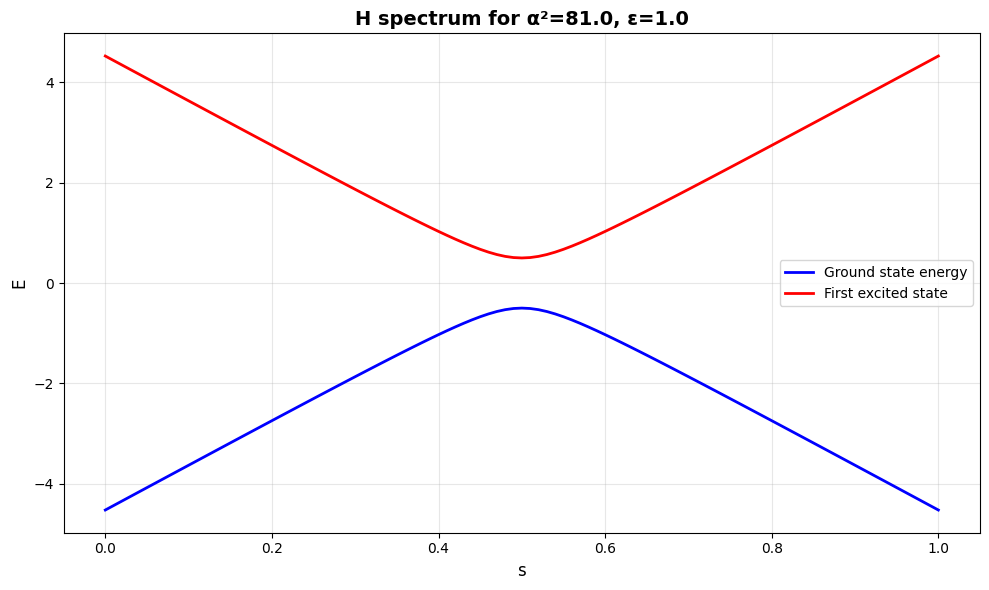

In [25]:
alpha = 9
epsilon = 1
t_list = np.linspace(0, 1, 101)
g, e = [], []

for t in t_list:
    Ham = H_numpy(alpha, epsilon, t)
    eigvals, eigvecs = np.linalg.eigh(Ham)
    g.append(eigvals[0])
    e.append(eigvals[1])

# Create plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(t_list, g, label='Ground state energy', linewidth=2, color='blue', linestyle='-')
plt.plot(t_list, e, label='First excited state', linewidth=2, color='red', linestyle='-')

# Customize
plt.title(f'H spectrum for α²={alpha**2:.1f}, ε={epsilon:.1f}', fontsize=14, fontweight='bold')
plt.xlabel('s', fontsize=12)
plt.ylabel('E', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show
plt.tight_layout()
plt.show()

In [82]:
epsilon = 1
alpha = 1
ti = 0
tf = 1
nsteps = 1001

times = np.linspace(ti, tf, nsteps)

H_i = H_numpy(alpha, epsilon, 0)
eigvals_i, eigvecs_i = np.linalg.eigh(H_i)

H_f = H_numpy(alpha, epsilon, 1)
eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

psi0 = eigvecs_i[0][0]*ket0 + eigvecs_i[0][1]*ket1

H = H_qutip(epsilon, alpha)

result = qt.sesolve(H, psi0, times)

final_state = result.states[-1]

dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])
pc = dot_c*dot_c.conj()
pe = dot_e*dot_e.conj()

print("Ground state probability:", pc)
print("Excited state probability:", pe)

print("normalization of probabilities", pc + pe)


Ground state probability: (0.5402089696061636-2.2766325565890468e-17j)
Excited state probability: (0.4597910303938368-1.3560717025258876e-23j)
normalization of probabilities (1.0000000000000004-2.2766339126607494e-17j)
